In [23]:
import os
import pandas as pd
import numpy as np
import pathlib
from copy import deepcopy

In [24]:
methods = ["fam-sim", "rnadist", "samples", "herarchical_cluster"]
fams = os.listdir("fam-sim/1_epoch")
epochs = [f"{i}_epoch" for i in range(1, 16)]
dist = [f"dist_{i}" for i in [100, 200, 400]]

print(fams)
print(epochs)
print(dist)

['23s', 'telomerase', '16s', '5s', 'grp1', 'srp', 'RNaseP', 'tmRNA', 'tRNA']
['1_epoch', '2_epoch', '3_epoch', '4_epoch', '5_epoch', '6_epoch', '7_epoch', '8_epoch', '9_epoch', '10_epoch', '11_epoch', '12_epoch', '13_epoch', '14_epoch', '15_epoch']
['dist_100', 'dist_200', 'dist_400']


In [25]:
metrics = {}
template = {"train": pd.DataFrame(), "test": pd.DataFrame()}
for m in methods:
    if m == "fam-sim":
        metrics[m] = deepcopy(template)
    else:
        metrics[m] = {}
        for d in dist:
            metrics[m][d] = deepcopy(template)

In [26]:
def log_and_concat(df, path, epoch, fam):
    new = pd.read_csv(path)
    new["epoch"] = epoch
    new["fam"] = fam
    return pd.concat([df, new], ignore_index=True)

In [27]:
# Esta celda acumula los resultados, si se corre 2 veces quedan duplicados.

for m in methods:
    for f in fams:
        for i, e in enumerate(epochs):
            if m == "fam-sim":
                PATH = pathlib.Path(f"{m}/{e}/{f}/")
                train = PATH / "train_log.csv"
                test = PATH / "test.csv"
                metrics[m]["train"] = log_and_concat(metrics[m]["train"], train, i, f)
                metrics[m]["test"] = log_and_concat(metrics[m]["test"], test, i, f)

            else:
                for d in dist:
                    PATH = pathlib.Path(f"{m}/{d}/{e}/{f}/")
                    train = PATH / "train_log.csv"
                    test = PATH / "test.csv"
                    metrics[m][d]["train"] = log_and_concat(
                        metrics[m][d]["train"], train, i, f
                    )
                    metrics[m][d]["test"] = log_and_concat(
                        metrics[m][d]["test"], test, i, f
                    )

In [28]:
df = metrics["fam-sim"]["test"]
df
# Vamos a hacer estadisticas de mejores resultados por familia y epoch, considerando media entre todas las familas para una epoca y la mejor epoca para cada familia.

,f1,f1_post,loss,epoch,fam
0,0.375,0.423,0.029,0,23s
1,0.379,0.384,0.045,1,23s
2,0.213,0.210,0.084,2,23s
3,0.329,0.327,0.058,3,23s
4,0.257,0.246,0.095,4,23s
...,...,...,...,...,...
130,0.593,0.603,0.197,10,tRNA
131,0.565,0.568,0.260,11,tRNA
132,0.503,0.505,0.300,12,tRNA
133,0.534,0.536,0.300,13,tRNA


In [29]:
df.drop_duplicates().query('fam=="telomerase"')

,f1,f1_post,loss,epoch,fam
15,0.223,0.195,0.026,0,telomerase
16,0.235,0.209,0.028,1,telomerase
17,0.130,0.112,0.040,2,telomerase
18,0.158,0.136,0.043,3,telomerase
19,0.183,0.172,0.037,4,telomerase
20,0.188,0.174,0.045,5,telomerase
21,0.179,0.150,0.045,6,telomerase
22,0.157,0.135,0.045,7,telomerase
23,0.149,0.126,0.066,8,telomerase
24,0.170,0.145,0.047,9,telomerase


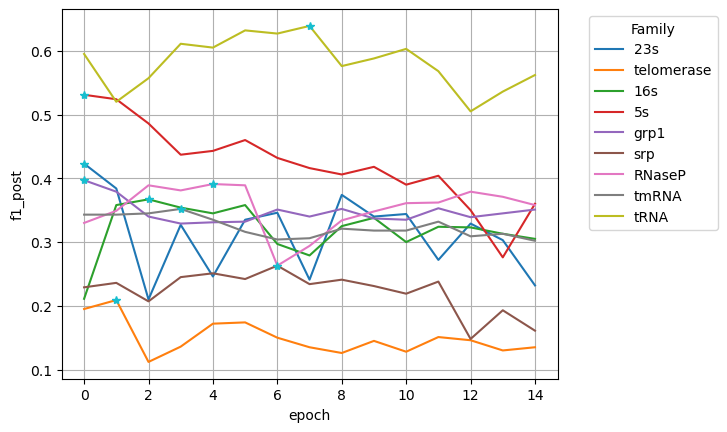

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt


df = metrics["fam-sim"]["test"].copy()
df.set_index(["epoch"], inplace=True)

f = sns.lineplot(
    data=df,
    x="epoch",
    y="f1_post",
    hue="fam",
    # legend,
)
max = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
ids = [df.query("fam == @f")["f1_post"].idxmax() for f in fams]
plt.plot(
    ids,
    max,
    "*",
    # color=colors,
)

plt.grid()
plt.legend(title="Family", bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [107]:
import seaborn as sns
import numpy as np


def plot_f1_test(data, y, ax):
    df = data.copy()
    fams = df["fam"].unique()

    # Dibujar líneas de cada familia
    sns.lineplot(
        data=df,
        x="epoch",
        y=y,
        hue="fam",
        ax=ax,
    )

    # Obtener colores por familia
    handles, labels = ax.get_legend_handles_labels()
    fam_color_map = {
        label: handle.get_color()
        for handle, label in zip(handles, labels)
        if label in fams
    }

    # Para cada familia, buscar el máximo y anotar
    for fam in fams:
        subdf = df[df["fam"] == fam]
        max_idx = subdf[y].idxmax()
        max_epoch = subdf.loc[max_idx, "epoch"]
        max_val = subdf.loc[max_idx, y]

        # Dibujar estrella
        ax.scatter(
            max_epoch,
            max_val,
            marker="*",
            color=fam_color_map[fam],
            s=150,
            edgecolor="black",
            zorder=5,
        )

        # Anotar con nombre de familia y número de época
        ax.annotate(
            f"{int(max_epoch)} ({fam})",
            (max_epoch, max_val),
            textcoords="offset points",
            xytext=(20, 10),  # desplazamiento vertical
            ha="center",
            fontsize=9,
            color="black",
            weight="bold",
        )

    ax.grid()
    ax.legend([])
    return ax

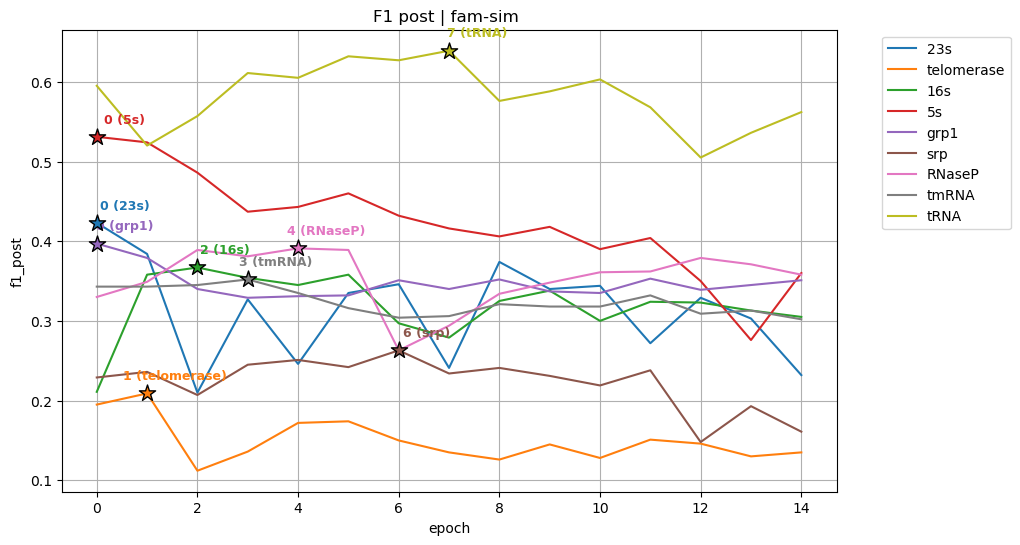

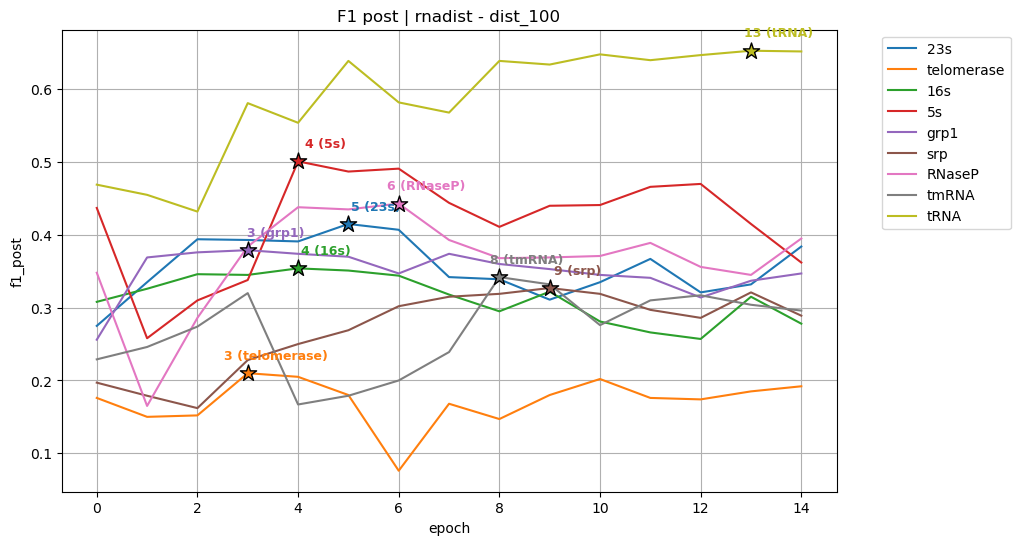

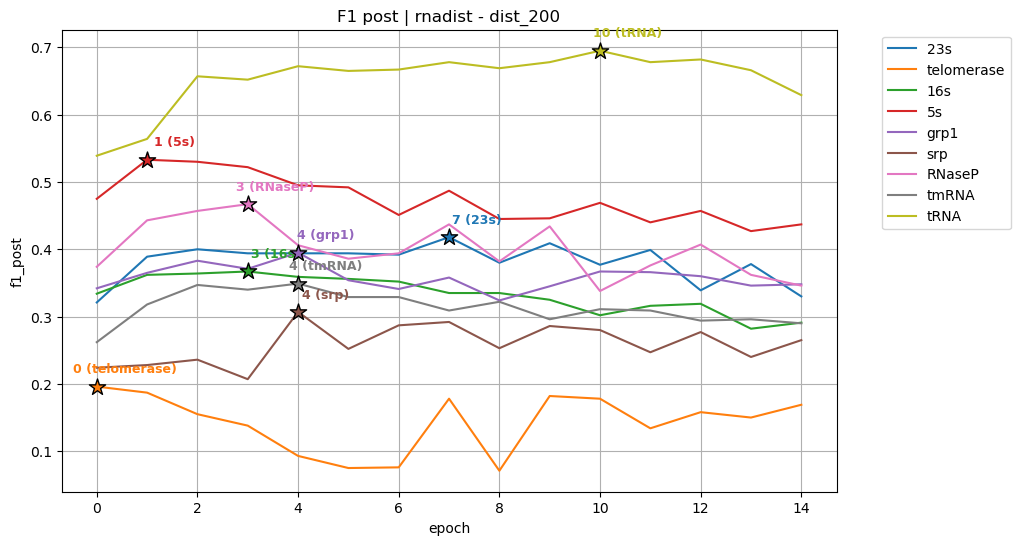

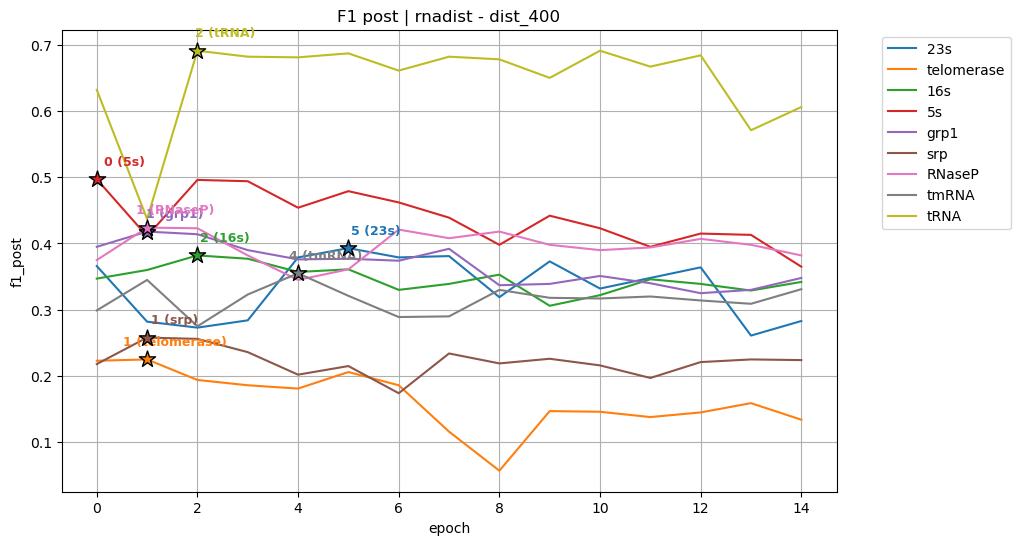

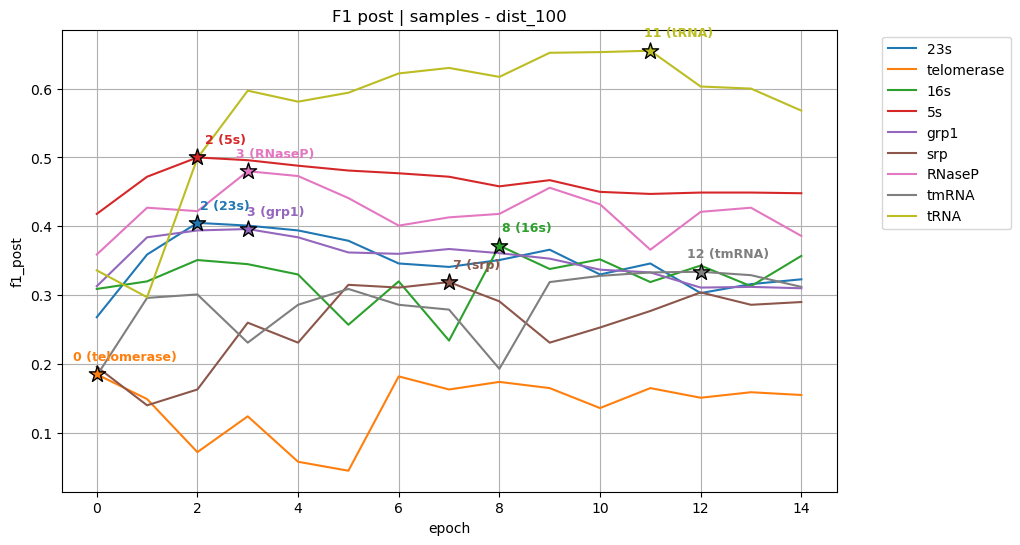

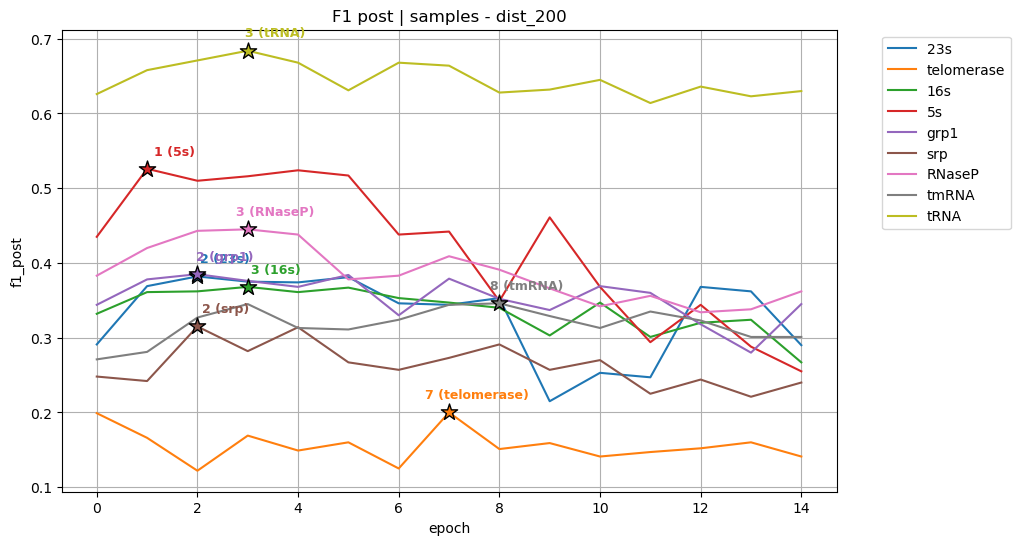

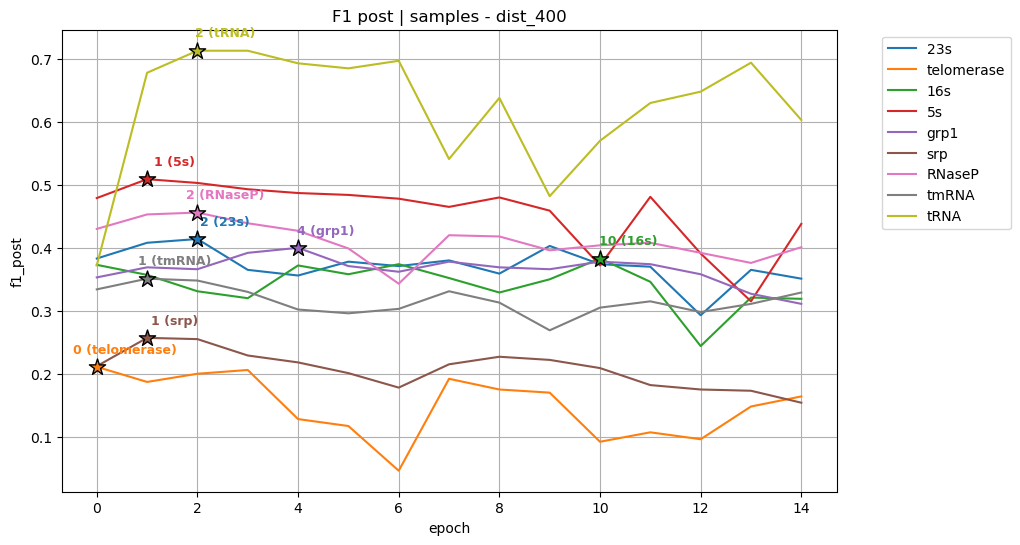

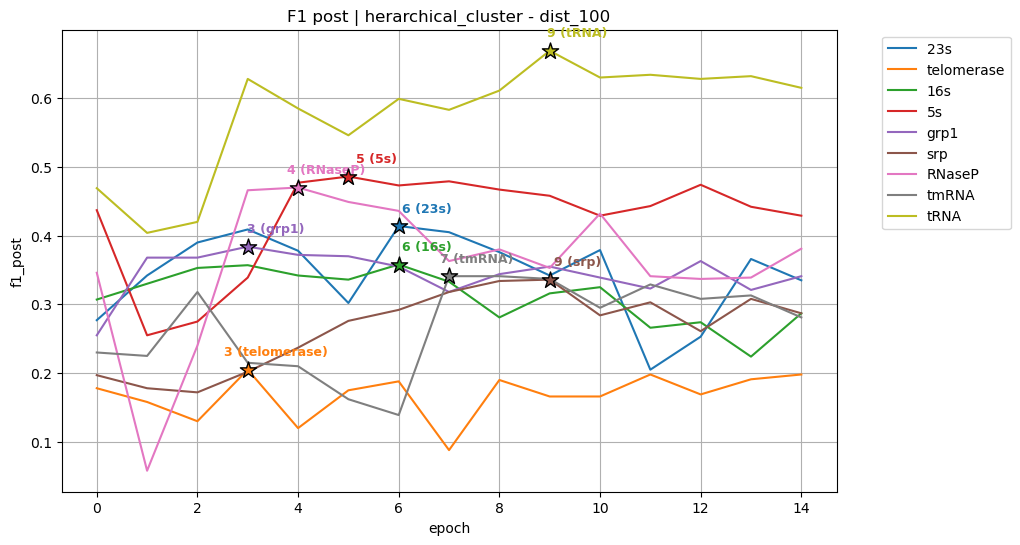

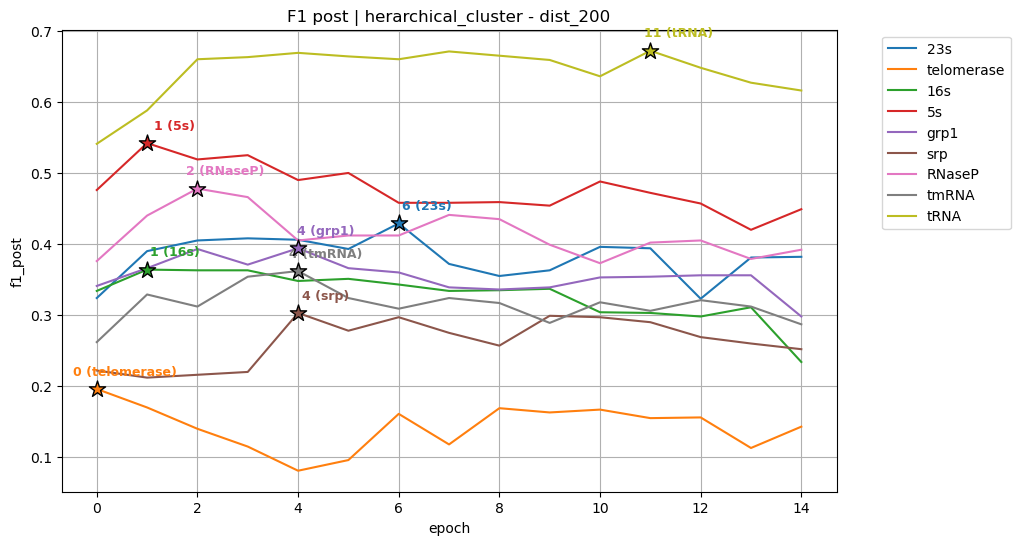

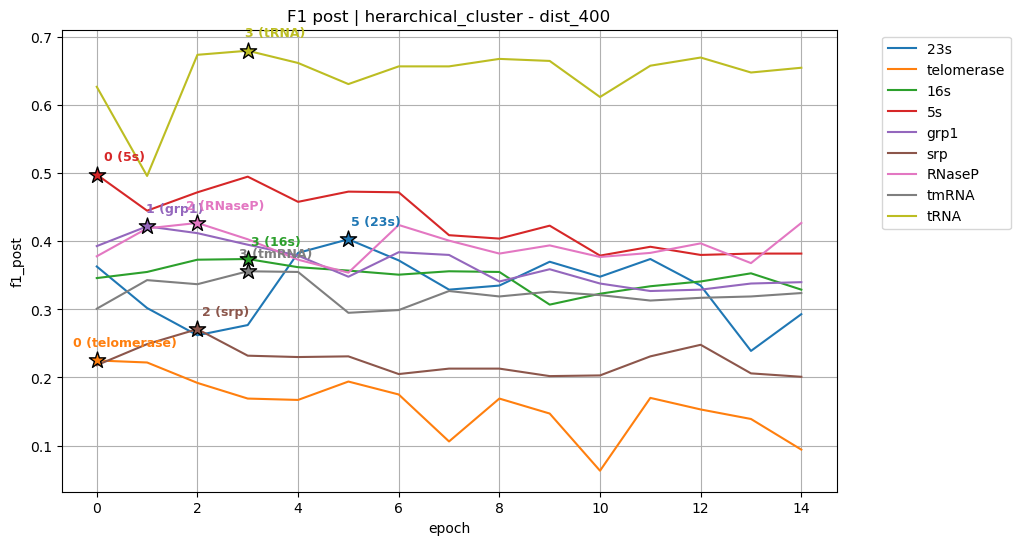

In [103]:
y = "f1_post"
for m in methods:
    if m == "fam-sim":
        plt.figure(figsize=(10, 6))
        ax1 = plt.subplot(1, 1, 1)
        ax1 = plot_f1_test(metrics[m]["test"], y, ax1)
        ax1.set_title(f"F1 post | {m} ")
        plt.show()
    else:
        for d in dist:
            plt.figure(figsize=(10, 6))
            ax1 = plt.subplot(1, 1, 1)
            ax1 = plot_f1_test(metrics[m][d]["test"], y, ax1)
            ax1.set_title(f"F1 post | {m} - {d}")
            plt.show()

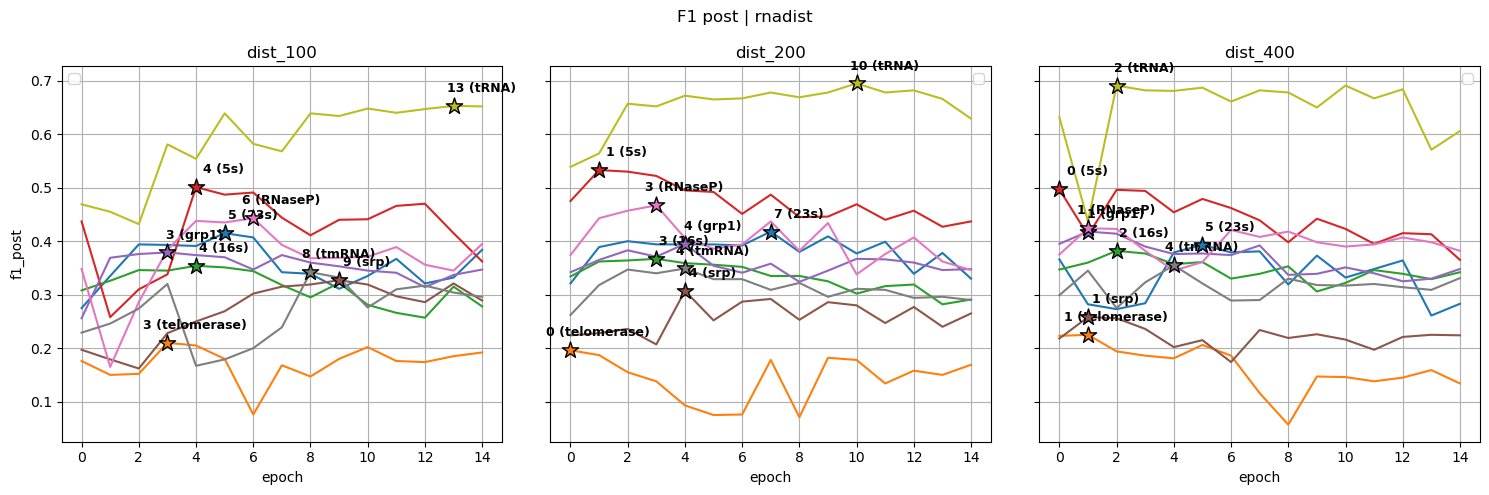

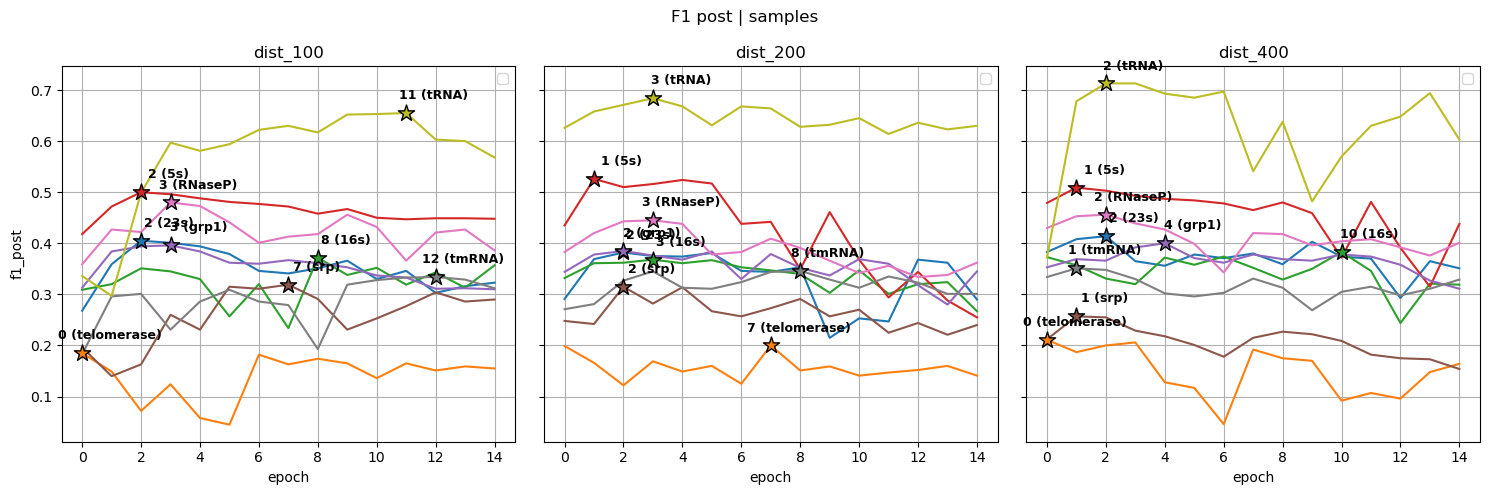

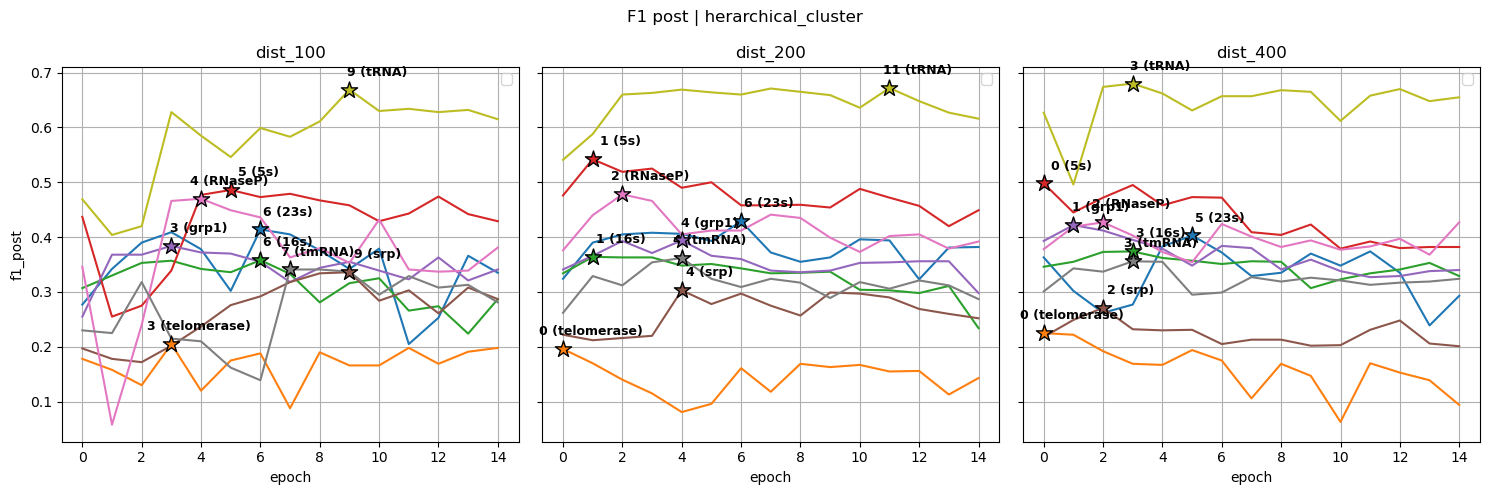

In [110]:
for m in methods:
    if m == "fam-sim":
        continue
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for i, d in enumerate(dist):
        ax[i] = plot_f1_test(metrics[m][d]["test"], y, ax[i])
        ax[i].set_title(f"{d}")
    fig.suptitle(f"F1 post | {m}")
    fig.tight_layout()
    plt.show()

In [112]:
methods

['fam-sim', 'rnadist', 'samples', 'herarchical_cluster']

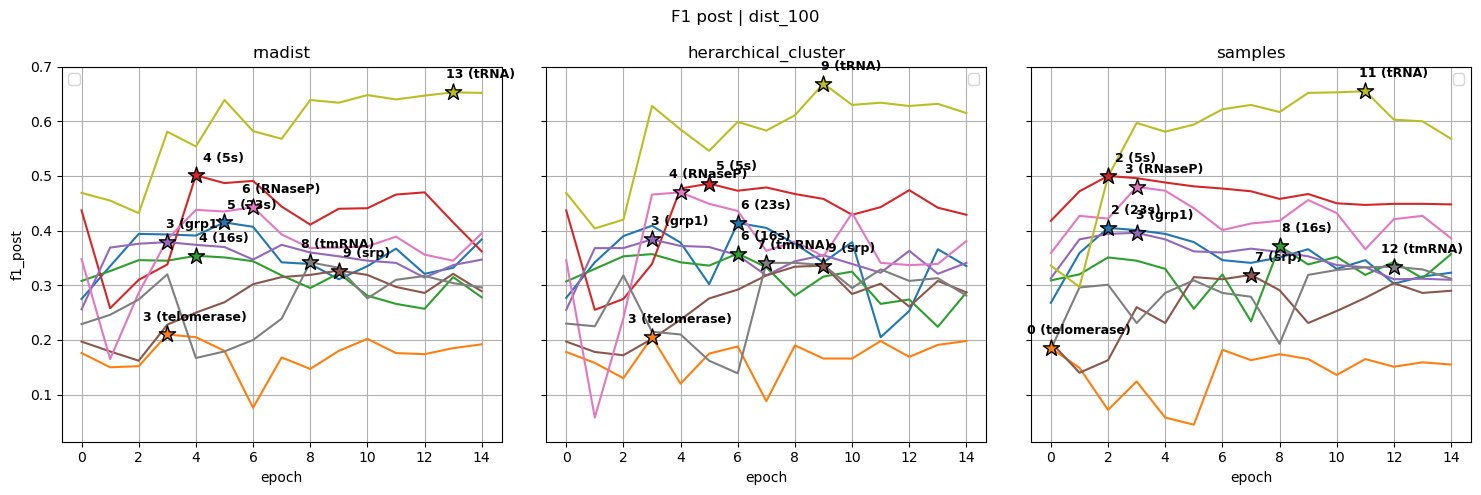

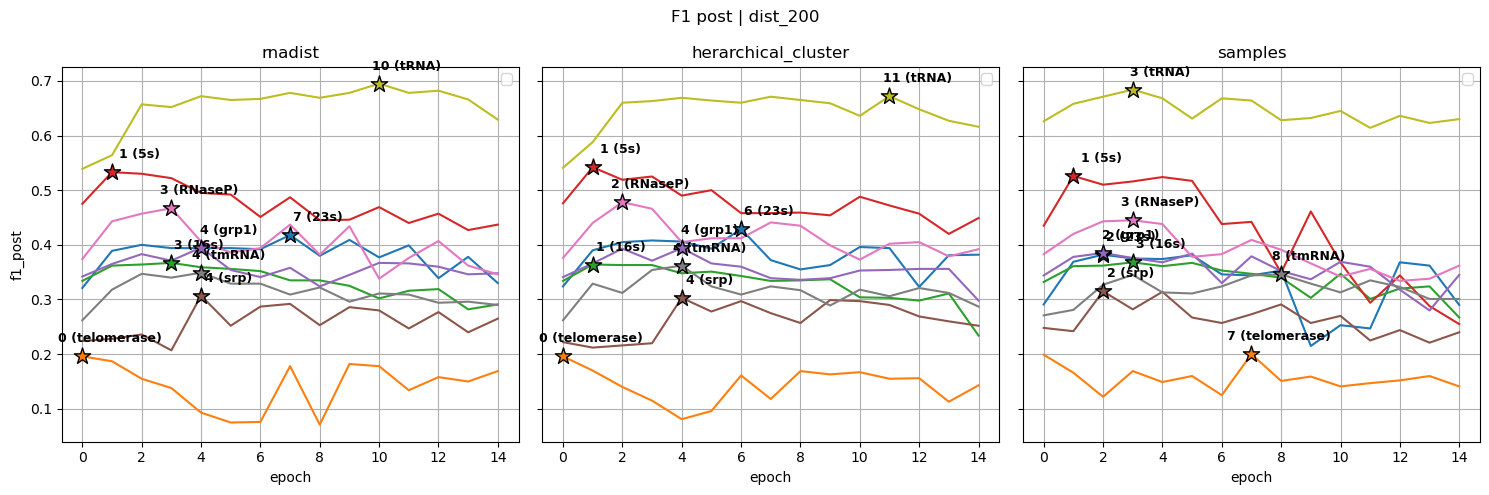

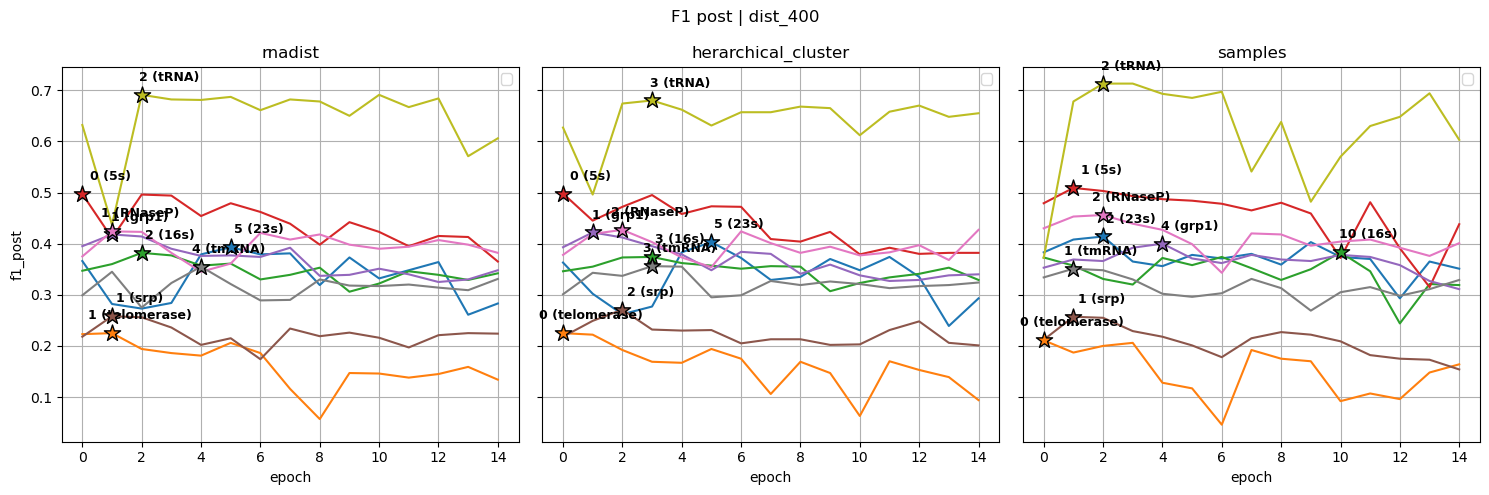

In [114]:
for d in dist:
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for i, m in enumerate(
        [
            "rnadist",
            "herarchical_cluster",
            "samples",
        ]
    ):
        ax[i] = plot_f1_test(metrics[m][d]["test"], y, ax[i])
        ax[i].set_title(f"{m}")
    fig.suptitle(f"F1 post | {d}")
    fig.tight_layout()
    plt.show()

In [14]:
# y = "valid_f1_post"
# for m in methods:
#     if m == "fam-sim":
#         plt.figure(figsize=(10, 6))
#         ax1 = plt.subplot(1, 1, 1)
#         ax1 = plot_f1_test(metrics[m]["train"], y, ax1)
#         ax1.set_title(f"F1 post | {m} ")
#         plt.show()
#     else:
#         for d in dist:
#             plt.figure(figsize=(10, 6))
#             ax1 = plt.subplot(1, 1, 1)
#             ax1 = plot_f1_test(metrics[m][d]["train"], y, ax1)
#             ax1.set_title(f"F1 post | {m} - {d}")
#             plt.show()

In [15]:
df = metrics[m][d]["test"]

In [16]:
means = [np.mean(df.query("epoch == @e")["f1_post"]) for e in range(0, 10)]
best = np.max(means)
best_epoch = means.index(best)
print(best_epoch, best)

2 0.38


In [134]:
print("Mejor f1 promedio entre las epoca para cada metodo")
for m in methods:
    if m == "fam-sim":
        df = metrics[m]["test"]
        means = [np.mean(df.query("epoch == @e")["f1_post"]) for e in range(0, 10)]
        best = np.max(means)
        best_epoch = means.index(best)
        print(
            f"Method: {m:<20}| Distance: 0\t         ep: {best_epoch} |f1_promedio: {round(best, 3)}"
        )

    else:
        for d in dist:

            df = metrics[m][d]["test"]
            means = [np.mean(df.query("epoch == @e")["f1_post"]) for e in range(0, 10)]
            best = np.max(means)
            best_epoch = means.index(best)
            print(
                f"Method: {m:<20}| Distance: {d}\t ep: {best_epoch} |f1_promedio: {round(best, 3)}"
            )

Mejor f1 promedio entre las epoca para cada metodo
Method: fam-sim             | Distance: 0	         ep: 1 |f1_promedio: 0.367
Method: rnadist             | Distance: dist_100	 ep: 5 |f1_promedio: 0.369
Method: rnadist             | Distance: dist_200	 ep: 2 |f1_promedio: 0.392
Method: rnadist             | Distance: dist_400	 ep: 2 |f1_promedio: 0.378
Method: samples             | Distance: dist_100	 ep: 9 |f1_promedio: 0.372
Method: samples             | Distance: dist_200	 ep: 3 |f1_promedio: 0.396
Method: samples             | Distance: dist_400	 ep: 2 |f1_promedio: 0.398
Method: herarchical_cluster | Distance: dist_100	 ep: 9 |f1_promedio: 0.37
Method: herarchical_cluster | Distance: dist_200	 ep: 2 |f1_promedio: 0.387
Method: herarchical_cluster | Distance: dist_400	 ep: 2 |f1_promedio: 0.38


In [ ]:
print("mejor valor y epoca por familia y metodo")
for m in methods:
    if m == "fam-sim":
        print(12 * "#")
        print(f"Method: {m}")
        print(12 * "#")
        df = metrics[m]["test"]
        max = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
        ids = [df.set_index(["epoch"]).query("fam == @f")[y].idxmax() for f in fams]
        for i, f in enumerate(fams):
            print(f"{f:<10}: Epoch {ids[i]}, F1 post max| {max[i]}")
        print("Promedio: ", round(np.mean(max), 3))
    else:
        for d in dist:
            df = metrics[m][d]["test"]
            print(12 * "#")
            print(f"Method: {m}| Distance: {d}")
            print(12 * "#")
            max = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
            ids = [df.set_index(["epoch"]).query("fam == @f")[y].idxmax() for f in fams]
            for i, f in enumerate(fams):
                print(f"{f:<10}: Epoch {ids[i]}, F1 post max| {round(max[i], 3)}")
            print("Promedio: ", round(np.mean(max), 3))

mejor valor y epoca por familia y metodo
############
Method: fam-sim
############
23s       : Epoch 0, F1 post max| 0.423
telomerase: Epoch 1, F1 post max| 0.209
16s       : Epoch 2, F1 post max| 0.367
5s        : Epoch 0, F1 post max| 0.531
grp1      : Epoch 0, F1 post max| 0.397
srp       : Epoch 6, F1 post max| 0.263
RNaseP    : Epoch 4, F1 post max| 0.391
tmRNA     : Epoch 3, F1 post max| 0.352
tRNA      : Epoch 7, F1 post max| 0.639
Promedio:  0.397
############
Method: rnadist| Distance: dist_100
############
23s       : Epoch 5, F1 post max| 0.415
telomerase: Epoch 3, F1 post max| 0.21
16s       : Epoch 4, F1 post max| 0.354
5s        : Epoch 4, F1 post max| 0.501
grp1      : Epoch 3, F1 post max| 0.379
srp       : Epoch 9, F1 post max| 0.327
RNaseP    : Epoch 6, F1 post max| 0.443
tmRNA     : Epoch 8, F1 post max| 0.342
tRNA      : Epoch 13, F1 post max| 0.653
Promedio:  0.403
############
Method: rnadist| Distance: dist_200
############
23s       : Epoch 7, F1 post max| 0.418

In [140]:
print("mejor f1 promedio entre todos los valores por familia y metodo")
for m in methods:
    if m == "fam-sim":
        df = metrics[m]["test"]
        max = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
        ids = [df.set_index(["epoch"]).query("fam == @f")[y].idxmax() for f in fams]
        print(
            f"Method: {m:<20}| Distance: None    \t| f1_promedio: {round(np.mean(max), 3)}"
        )

    else:
        for d in dist:
            df = metrics[m][d]["test"]
            max = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
            ids = [df.set_index(["epoch"]).query("fam == @f")[y].idxmax() for f in fams]
            print(
                f"Method: {m:<20}| Distance: {d}\t| f1_promedio: {round(np.mean(max), 3)}"
            )

mejor f1 promedio entre todos los valores por familia y metodo
Method: fam-sim             | Distance: None    	| f1_promedio: 0.397
Method: rnadist             | Distance: dist_100	| f1_promedio: 0.403
Method: rnadist             | Distance: dist_200	| f1_promedio: 0.414
Method: rnadist             | Distance: dist_400	| f1_promedio: 0.405
Method: samples             | Distance: dist_100	| f1_promedio: 0.405
Method: samples             | Distance: dist_200	| f1_promedio: 0.406
Method: samples             | Distance: dist_400	| f1_promedio: 0.41
Method: herarchical_cluster | Distance: dist_100	| f1_promedio: 0.407
Method: herarchical_cluster | Distance: dist_200	| f1_promedio: 0.416
Method: herarchical_cluster | Distance: dist_400	| f1_promedio: 0.406


In [125]:
best_results = {}

print("mejor valor y epoca por familia y metodo")
for m in methods:
    if m == "fam-sim":
        print(12 * "#")
        print(f"Method: {m}")
        print(12 * "#")
        df = metrics[m]["test"]
        max_list = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
        ids = [df.set_index(["epoch"]).query("fam == @f")[y].idxmax() for f in fams]
        for i, f in enumerate(fams):
            f1_val = max_list[i]
            epoch = ids[i]
            print(f"{f:<10}: Epoch {epoch}, F1 post max| {round(f1_val, 3)}")

            # actualizar mejor resultado
            if f not in best_results or f1_val > best_results[f]["f1"]:
                best_results[f] = {
                    "f1": f1_val,
                    "epoch": epoch,
                    "method": m,
                    "distance": None,
                }

        print("Promedio: ", round(np.mean(max_list), 3))
    else:
        for d in dist:
            df = metrics[m][d]["test"]
            print(12 * "#")
            print(f"Method: {m}| Distance: {d}")
            print(12 * "#")
            max_list = [np.max(df.query("fam == @f")["f1_post"]) for f in fams]
            ids = [df.set_index(["epoch"]).query("fam == @f")[y].idxmax() for f in fams]
            for i, f in enumerate(fams):
                f1_val = max_list[i]
                epoch = ids[i]
                print(f"{f:<10}: Epoch {epoch}, F1 post max| {round(f1_val, 3)}")

                # actualizar mejor resultado
                if f not in best_results or f1_val > best_results[f]["f1"]:
                    best_results[f] = {
                        "f1": f1_val,
                        "epoch": epoch,
                        "method": m,
                        "distance": d,
                    }

            print("Promedio: ", round(np.mean(max_list), 3))

mejor valor y epoca por familia y metodo
############
Method: fam-sim
############
23s       : Epoch 0, F1 post max| 0.423
telomerase: Epoch 1, F1 post max| 0.209
16s       : Epoch 2, F1 post max| 0.367
5s        : Epoch 0, F1 post max| 0.531
grp1      : Epoch 0, F1 post max| 0.397
srp       : Epoch 6, F1 post max| 0.263
RNaseP    : Epoch 4, F1 post max| 0.391
tmRNA     : Epoch 3, F1 post max| 0.352
tRNA      : Epoch 7, F1 post max| 0.639
Promedio:  0.397
############
Method: rnadist| Distance: dist_100
############
23s       : Epoch 5, F1 post max| 0.415
telomerase: Epoch 3, F1 post max| 0.21
16s       : Epoch 4, F1 post max| 0.354
5s        : Epoch 4, F1 post max| 0.501
grp1      : Epoch 3, F1 post max| 0.379
srp       : Epoch 9, F1 post max| 0.327
RNaseP    : Epoch 6, F1 post max| 0.443
tmRNA     : Epoch 8, F1 post max| 0.342
tRNA      : Epoch 13, F1 post max| 0.653
Promedio:  0.403
############
Method: rnadist| Distance: dist_200
############
23s       : Epoch 7, F1 post max| 0.418

In [ ]:
import pandas as pd

best_df = pd.DataFrame.from_dict(best_results, orient="index")
best_df.index.name = "fam"
print("Mejores Resultados por familia:")
best_df

Mejores Resultados por familia:


,f1,epoch,method,distance
fam,,,,
23s,0.429,6,herarchical_cluster,dist_200
telomerase,0.225,1,rnadist,dist_400
16s,0.383,10,samples,dist_400
5s,0.542,1,herarchical_cluster,dist_200
grp1,0.422,1,herarchical_cluster,dist_400
srp,0.336,9,herarchical_cluster,dist_100
RNaseP,0.480,3,samples,dist_100
tmRNA,0.362,4,herarchical_cluster,dist_200
tRNA,0.713,2,samples,dist_400
